In [21]:
import numpy as np
import random
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [22]:
# Load battery data
Battery_list = ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']
Battery = np.load('datasets/CALCE/CALCE.npy', allow_pickle=True)
Battery = Battery.item()

# Select first battery for this example
test_battery_name = 'CS2_35'
df_result = Battery[test_battery_name]
print(f"Loaded battery: {test_battery_name}")
print(f"Data shape: {df_result.shape}")
print(f"Columns: {df_result.columns.tolist()}")

Loaded battery: CS2_35
Data shape: (882, 6)
Columns: ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']


In [23]:
# Helper functions (aligned with Transformer notebook)
def build_sequences(text, window_size):
    """Convert 1D array into sliding window sequences."""
    x, y = [], []
    for i in range(len(text) - window_size):
        sequence = text[i:i + window_size]
        target = text[i + window_size]
        x.append(sequence)
        y.append(target)
    return np.array(x), np.array(y)

def build_sequences_multivariate(df, feature_cols, target_col, window_size):
    """Build multivariate sliding windows with a single-step target."""
    values_x = df[feature_cols].values.astype(np.float32)
    values_y = df[target_col].values.astype(np.float32)

    x, y = [], []
    for i in range(len(df) - window_size):
        x.append(values_x[i:i + window_size])
        y.append(values_y[i + window_size])

    return np.array(x, dtype=np.float32), np.array(y, dtype=np.float32)

def select_input_features(df, target_col='SoH', require_core_signals=False):
    """Select multivariate inputs and prefer voltage/current/temperature when available."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    candidate_cols = [c for c in numeric_cols if c != target_col]

    core_aliases = {
        'voltage': ['voltage', 'volt', 'v_'],
        'current': ['current', 'curr', 'i_'],
        'temperature': ['temperature', 'temp', 't_']
    }

    core_found = []
    missing_core = []

    for signal_name, aliases in core_aliases.items():
        matched = [c for c in candidate_cols if any(a in c.lower() for a in aliases)]
        if len(matched) == 0:
            missing_core.append(signal_name)
        else:
            core_found.extend(matched)

    if require_core_signals and len(missing_core) > 0:
        raise ValueError(
            f"Missing required core input signals: {missing_core}. "
            f"Available numeric columns: {numeric_cols}"
        )

    useful_aliases = ['cycle', 'resistance', 'ir', 'capacity', 'ccct', 'cvct', 'dqdv', 'energy', 'power']
    useful_cols = [
        c for c in candidate_cols
        if c not in core_found and any(a in c.lower() for a in useful_aliases)
    ]

    remaining_cols = [c for c in candidate_cols if c not in core_found and c not in useful_cols]
    feature_cols = core_found + useful_cols + remaining_cols
    return feature_cols, core_found, missing_core

def setup_seed(seed):
    """Set random seeds for reproducibility."""
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


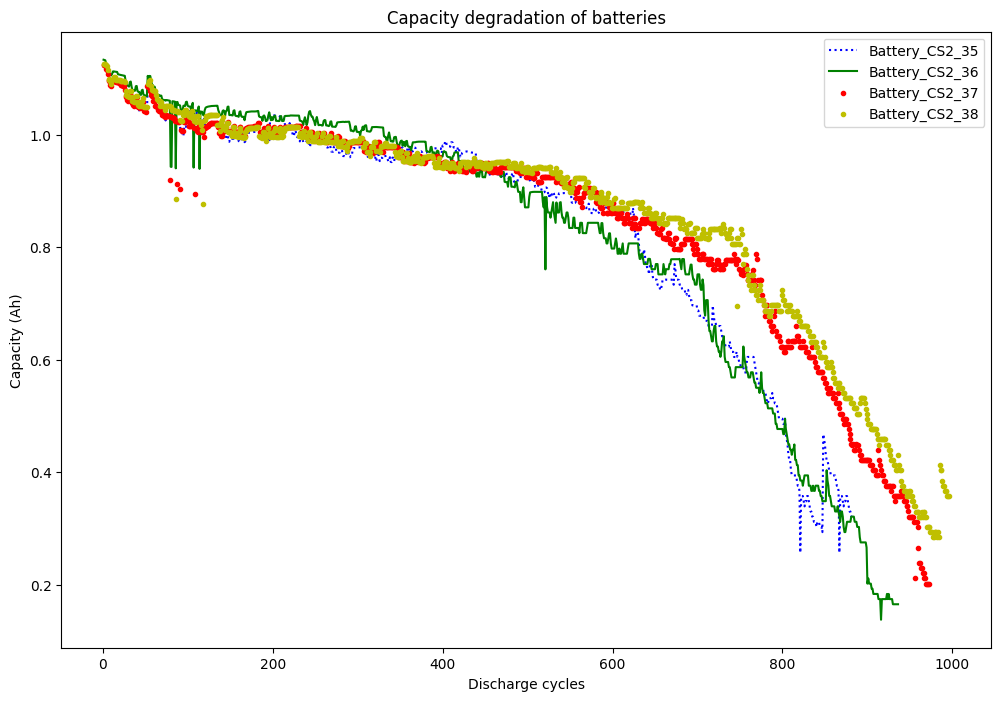

In [24]:
# Visualize capacity degradation for all batteries
fig, ax = plt.subplots(1, figsize=(12, 8))
color_list = ['b:', 'g', 'r.', 'y.']
for name, color in zip(Battery_list, color_list):
    df_battery = Battery[name]
    ax.plot(df_battery['cycle'], df_battery['capacity'], color, label='Battery_' + name)
ax.set(xlabel='Discharge cycles', ylabel='Capacity (Ah)', title='Capacity degradation of batteries')
plt.legend()
plt.show()

In [25]:
# DNN model definition (same input/output style as Transformer pipeline)
class DNN_SOHPredictor(nn.Module):
    """DNN that consumes [batch, window, features] and predicts next-step SoH."""
    def __init__(self, window_size, input_dim, hidden_layers=[256, 128, 64], dropout_rate=0.3):
        super().__init__()
        layers = []

        in_features = window_size * input_dim
        for out_features in hidden_layers:
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_features = out_features

        layers.append(nn.Linear(in_features, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Flatten temporal and feature dimensions
        x = x.reshape(x.size(0), -1)
        return self.net(x)

# Preview with placeholder feature count; real model is created in training cells
preview_input_dim = 8
preview_window_size = int(globals().get('window_size', 8))

if 'window_size' not in globals():
    print(f"window_size not defined yet; using preview_window_size={preview_window_size} for model preview.")

dnn_preview = DNN_SOHPredictor(window_size=preview_window_size, input_dim=preview_input_dim).to(device)
print(dnn_preview)
print(
    f"DNN parameters (preview, window_size={preview_window_size}, input_dim={preview_input_dim}): "
    f"{sum(p.numel() for p in dnn_preview.parameters()):,}"
)

DNN_SOHPredictor(
  (net): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
  )
)
DNN parameters (preview, window_size=16, input_dim=8): 74,241


In [26]:
# Training utilities (same training behavior as Transformer notebook)
def eval_loader_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    preds_all, targets_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb).squeeze(-1)
            loss = criterion(pred, yb)
            running_loss += loss.item() * xb.size(0)
            preds_all.append(pred.cpu().numpy())
            targets_all.append(yb.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    return avg_loss, np.concatenate(preds_all), np.concatenate(targets_all)

Found existing training losses; skipping baseline training.


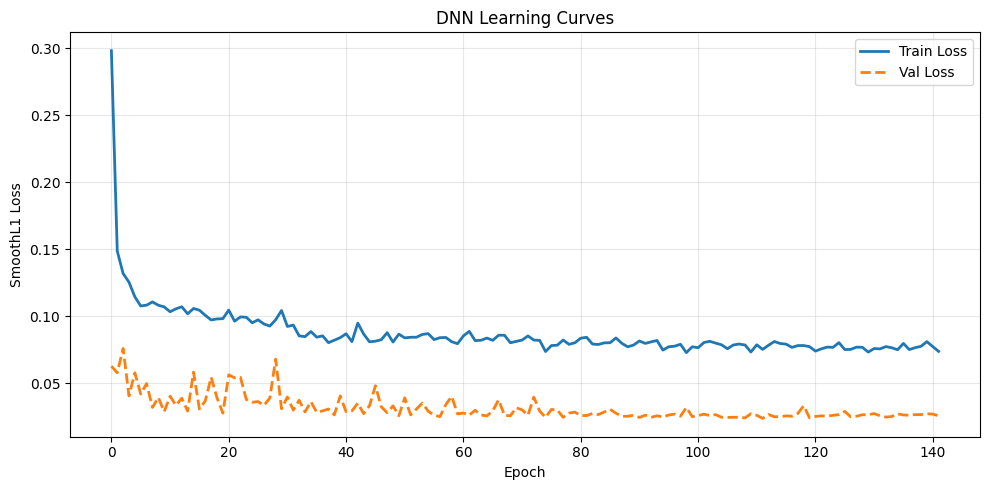

In [27]:
# Baseline DNN training (runs if training losses are missing) and plotting of learning curves.
# This cell will run a full baseline training for 300 epochs when `train_losses_dnn` is not present.
if 'train_losses_dnn' not in globals() or 'val_losses_dnn' not in globals():
    print('Training variables not found — running baseline DNN training for 300 epochs...')

    setup_seed(42)

    test_battery_name = globals().get('test_battery_name', 'CS2_35')
    future_battery_name = globals().get('future_battery_name', 'CS2_37')
    window_size = int(globals().get('window_size', 16))
    batch_size = int(globals().get('batch_size', 32))
    target_col = 'SoH'

    # Use only numeric columns shared by all batteries
    common_numeric_cols = sorted(set.intersection(*[
        set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
    ]))

    feature_cols, core_signal_cols, missing_core_signals = select_input_features(
        Battery[test_battery_name][common_numeric_cols],
        target_col=target_col,
        require_core_signals=False,
    )

    # Strict hold-out batteries
    train_batteries = [b for b in Battery_list if b not in [test_battery_name, future_battery_name]]

    X_train_all, y_train_all = [], []
    for battery_name in train_batteries:
        df_bat = Battery[battery_name][feature_cols + [target_col]].dropna().copy()
        X_tmp, y_tmp = build_sequences_multivariate(df_bat, feature_cols=feature_cols, target_col=target_col, window_size=window_size)
        X_train_all.append(X_tmp)
        y_train_all.append(y_tmp)

    X_train_all = np.vstack(X_train_all)
    y_train_all = np.hstack(y_train_all)

    # Test / future sets
    df_test = Battery[test_battery_name][feature_cols + [target_col]].dropna().copy()
    X_test_raw, y_test_raw = build_sequences_multivariate(df_test, feature_cols=feature_cols, target_col=target_col, window_size=window_size)

    df_future = Battery[future_battery_name][feature_cols + [target_col]].dropna().copy()
    X_future_raw, y_future_raw = build_sequences_multivariate(df_future, feature_cols=feature_cols, target_col=target_col, window_size=window_size)

    # Validation split
    X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
        X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
    )

    # Scale (3D -> 2D -> 3D)
    scaler_X_dnn = StandardScaler()
    scaler_y_dnn = StandardScaler()

    n_train, w_size, n_feat = X_train_raw.shape
    X_train_dnn = scaler_X_dnn.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

    n_val = X_val_raw.shape[0]
    X_val_dnn = scaler_X_dnn.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

    n_test = X_test_raw.shape[0]
    X_test_dnn = scaler_X_dnn.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

    n_future = X_future_raw.shape[0]
    X_future_dnn = scaler_X_dnn.transform(X_future_raw.reshape(-1, n_feat)).reshape(n_future, w_size, n_feat)

    y_train_dnn = scaler_y_dnn.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
    y_val_dnn = scaler_y_dnn.transform(y_val_raw.reshape(-1, 1)).ravel()
    y_test_dnn = scaler_y_dnn.transform(y_test_raw.reshape(-1, 1)).ravel()
    y_future_dnn = scaler_y_dnn.transform(y_future_raw.reshape(-1, 1)).ravel()

    train_loader_dnn = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_train_dnn, dtype=torch.float32), torch.tensor(y_train_dnn, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader_dnn = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_val_dnn, dtype=torch.float32), torch.tensor(y_val_dnn, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
    )
    test_loader_dnn = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_test_dnn, dtype=torch.float32), torch.tensor(y_test_dnn, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
    )
    future_loader_dnn = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_future_dnn, dtype=torch.float32), torch.tensor(y_future_dnn, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
    )

    # Model, optimizer, scheduler
    model_dnn = DNN_SOHPredictor(window_size=window_size, input_dim=n_feat).to(device)
    criterion_dnn = nn.SmoothL1Loss(beta=0.05)
    optimizer_dnn = optim.AdamW(model_dnn.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler_dnn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_dnn, mode='min', factor=0.5, patience=10, min_lr=1e-5)

    # Training loop (300 epochs, early stopping)
    train_losses_dnn = []
    val_losses_dnn = []
    max_epochs = 300
    patience = 30
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(1, max_epochs + 1):
        model_dnn.train()
        running_train_loss = 0.0

        for xb, yb in train_loader_dnn:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_dnn.zero_grad()
            pred = model_dnn(xb).squeeze(-1)
            loss = criterion_dnn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_dnn.parameters(), max_norm=1.0)
            optimizer_dnn.step()

            running_train_loss += loss.item() * xb.size(0)

        train_loss = running_train_loss / len(train_loader_dnn.dataset)
        val_loss, _, _ = eval_loader_loss(model_dnn, val_loader_dnn, criterion_dnn)
        scheduler_dnn.step(val_loss)

        train_losses_dnn.append(train_loss)
        val_losses_dnn.append(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model_dnn.state_dict().items()}
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 20 == 0:
            current_lr = optimizer_dnn.param_groups[0]['lr']
            print(f"Epoch {epoch:3d}/{max_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.6f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch} (best val loss: {best_val_loss:.6f})")
            break

    # Restore best model
    if best_state is not None:
        model_dnn.load_state_dict(best_state)

    # Test evaluation
    test_loss_dnn, y_pred_test_scaled, y_test_scaled = eval_loader_loss(model_dnn, test_loader_dnn, criterion_dnn)
    y_pred_test_dnn = scaler_y_dnn.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).ravel()
    y_test_true_dnn = scaler_y_dnn.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

    rmse_dnn = np.sqrt(mean_squared_error(y_test_true_dnn, y_pred_test_dnn))
    mae_dnn = mean_absolute_error(y_test_true_dnn, y_pred_test_dnn)

    print(f"\nBaseline DNN Test RMSE: {rmse_dnn:.6f}")
    print(f"Baseline DNN Test MAE : {mae_dnn:.6f}")

else:
    print('Found existing training losses; skipping baseline training.')

# Plot learning curves
fig = plt.figure(figsize=(10, 5))
plt.plot(train_losses_dnn, label='Train Loss', linewidth=2)
plt.plot(val_losses_dnn, label='Val Loss', linewidth=2, linestyle='--')
plt.title('DNN Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('SmoothL1 Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Hyperparameter tuning for the DNN model
# This single tuning cell is the active one used downstream.
setup_seed(42)

# Reuse the same split created by the baseline cell so the comparison is apples-to-apples.
X_train_raw_tune, X_val_raw_tune, y_train_raw_tune, y_val_raw_tune = train_test_split(
    X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
)

search_space = [
    {'hidden_layers': [256, 128, 64], 'dropout_rate': 0.30, 'lr': 1e-3, 'weight_decay': 1e-3, 'beta': 0.05},
    {'hidden_layers': [256, 128, 64], 'dropout_rate': 0.25, 'lr': 1e-3, 'weight_decay': 5e-4, 'beta': 0.05},
    {'hidden_layers': [256, 128],     'dropout_rate': 0.10, 'lr': 1e-3, 'weight_decay': 5e-4, 'beta': 0.05},
    {'hidden_layers': [192, 96, 48],  'dropout_rate': 0.20, 'lr': 1e-3, 'weight_decay': 5e-4, 'beta': 0.05},
    {'hidden_layers': [128, 64],      'dropout_rate': 0.15, 'lr': 1e-3, 'weight_decay': 1e-4, 'beta': 0.05},
    {'hidden_layers': [128, 64],      'dropout_rate': 0.10, 'lr': 1e-3, 'weight_decay': 1e-4, 'beta': 0.05},
]

best_tune = None
all_tune_rows = []

for trial_idx, cfg in enumerate(search_space, 1):
    scaler_X_tmp = StandardScaler()
    scaler_y_tmp = StandardScaler()

    n_train_tmp, w_tmp, n_feat_tmp = X_train_raw_tune.shape
    X_train_tmp = scaler_X_tmp.fit_transform(X_train_raw_tune.reshape(-1, n_feat_tmp)).reshape(n_train_tmp, w_tmp, n_feat_tmp)

    n_val_tmp = X_val_raw_tune.shape[0]
    X_val_tmp = scaler_X_tmp.transform(X_val_raw_tune.reshape(-1, n_feat_tmp)).reshape(n_val_tmp, w_tmp, n_feat_tmp)

    y_train_tmp = scaler_y_tmp.fit_transform(y_train_raw_tune.reshape(-1, 1)).ravel()
    y_val_tmp = scaler_y_tmp.transform(y_val_raw_tune.reshape(-1, 1)).ravel()

    # Recompute late-life weighting threshold in scaled space for this trial's scaler.
    late_soh_threshold_tmp = 0.60
    late_weight_tmp = 1.5
    late_threshold_scaled_tmp = (late_soh_threshold_tmp - float(scaler_y_tmp.mean_[0])) / float(scaler_y_tmp.scale_[0])

    train_loader_tmp = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_train_tmp, dtype=torch.float32), torch.tensor(y_train_tmp, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader_tmp = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_val_tmp, dtype=torch.float32), torch.tensor(y_val_tmp, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
    )

    model_tmp = DNN_SOHPredictor(
        window_size=window_size,
        input_dim=n_feat_tmp,
        hidden_layers=cfg['hidden_layers'],
        dropout_rate=cfg['dropout_rate'],
    ).to(device)

    criterion_tmp = nn.SmoothL1Loss(beta=cfg['beta'])
    optimizer_tmp = optim.AdamW(model_tmp.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler_tmp = optim.lr_scheduler.ReduceLROnPlateau(optimizer_tmp, mode='min', factor=0.5, patience=8, min_lr=1e-5)

    best_val_loss_tmp = float('inf')
    best_state_tmp = None
    patience_counter_tmp = 0
    max_epochs_tmp = 220
    patience_tmp = 24

    for _ in range(max_epochs_tmp):
        model_tmp.train()
        for xb, yb in train_loader_tmp:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer_tmp.zero_grad()
            pred = model_tmp(xb).squeeze(-1)
            base_loss = criterion_tmp(pred, yb)
            late_mask = (yb < late_threshold_scaled_tmp)
            if late_mask.any():
                late_loss = criterion_tmp(pred[late_mask], yb[late_mask])
                loss = base_loss + late_weight_tmp * late_loss
            else:
                loss = base_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tmp.parameters(), max_norm=1.0)
            optimizer_tmp.step()

        val_loss_tmp, y_pred_val_scaled_tmp, y_true_val_scaled_tmp = eval_loader_loss(model_tmp, val_loader_tmp, criterion_tmp)
        scheduler_tmp.step(val_loss_tmp)

        if val_loss_tmp < best_val_loss_tmp - 1e-6:
            best_val_loss_tmp = val_loss_tmp
            best_state_tmp = {k: v.detach().cpu().clone() for k, v in model_tmp.state_dict().items()}
            patience_counter_tmp = 0
        else:
            patience_counter_tmp += 1

        if patience_counter_tmp >= patience_tmp:
            break

    if best_state_tmp is not None:
        model_tmp.load_state_dict(best_state_tmp)

    _, y_pred_val_scaled_tmp, y_true_val_scaled_tmp = eval_loader_loss(model_tmp, val_loader_tmp, criterion_tmp)
    y_pred_val_tmp = scaler_y_tmp.inverse_transform(y_pred_val_scaled_tmp.reshape(-1, 1)).ravel()
    y_true_val_tmp = scaler_y_tmp.inverse_transform(y_true_val_scaled_tmp.reshape(-1, 1)).ravel()

    rmse_val_tmp = float(np.sqrt(mean_squared_error(y_true_val_tmp, y_pred_val_tmp)))
    late_mask_raw_tmp = y_true_val_tmp < 0.60
    if np.any(late_mask_raw_tmp):
        rmse_late_tmp = float(np.sqrt(mean_squared_error(y_true_val_tmp[late_mask_raw_tmp], y_pred_val_tmp[late_mask_raw_tmp])))
    else:
        rmse_late_tmp = rmse_val_tmp

    # Keep validation RMSE primary so the tuner favors generalization to the held-out test battery.
    objective_tmp = rmse_val_tmp + 0.25 * rmse_late_tmp

    row = {
        'trial': trial_idx,
        'hidden_layers': str(cfg['hidden_layers']),
        'dropout_rate': cfg['dropout_rate'],
        'lr': cfg['lr'],
        'weight_decay': cfg['weight_decay'],
        'beta': cfg['beta'],
        'val_rmse': rmse_val_tmp,
        'late_val_rmse': rmse_late_tmp,
        'objective': objective_tmp,
    }
    all_tune_rows.append(row)

    if (best_tune is None) or (objective_tmp < best_tune['objective']):
        best_tune = {
            **row,
            'state_dict': {k: v.detach().cpu().clone() for k, v in model_tmp.state_dict().items()},
            'scaler_X': scaler_X_tmp,
            'scaler_y': scaler_y_tmp,
            'cfg': cfg,
        }

results_tuning = pd.DataFrame(all_tune_rows).sort_values('objective').reset_index(drop=True)
print('Top tuning trials (lower objective is better):')
print(results_tuning.head(6).to_string(index=False))

# Cache baseline hold-out predictions before tuned predictions overwrite shared arrays.
if 'y_pred_test_dnn' in globals() and 'y_test_true_dnn' in globals():
    y_pred_test_base_dnn = np.asarray(y_pred_test_dnn).copy()
    y_test_true_base_dnn = np.asarray(y_test_true_dnn).copy()

best_cfg = best_tune['cfg']

# Build the tuned model and refresh active training artifacts for downstream forecast cells
model_dnn_tuned = DNN_SOHPredictor(
    window_size=window_size,
    input_dim=len(feature_cols),
    hidden_layers=best_cfg['hidden_layers'],
    dropout_rate=best_cfg['dropout_rate'],
).to(device)
model_dnn_tuned.load_state_dict(best_tune['state_dict'])
model_dnn_tuned.eval()

scaler_X_dnn_tuned = best_tune['scaler_X']
scaler_y_dnn_tuned = best_tune['scaler_y']
criterion_eval = nn.SmoothL1Loss(beta=float(best_cfg['beta']))

# Refresh tensors/loaders with tuned scalers
n_train, w_size, n_feat = X_train_raw.shape
X_train_dnn = scaler_X_dnn_tuned.transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

n_val = X_val_raw.shape[0]
X_val_dnn = scaler_X_dnn_tuned.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

n_test = X_test_raw.shape[0]
X_test_dnn = scaler_X_dnn_tuned.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

n_future = X_future_raw.shape[0]
X_future_dnn = scaler_X_dnn_tuned.transform(X_future_raw.reshape(-1, n_feat)).reshape(n_future, w_size, n_feat)

y_train_dnn = scaler_y_dnn_tuned.transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_dnn = scaler_y_dnn_tuned.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_dnn = scaler_y_dnn_tuned.transform(y_test_raw.reshape(-1, 1)).ravel()
y_future_dnn = scaler_y_dnn_tuned.transform(y_future_raw.reshape(-1, 1)).ravel()

train_loader_dnn = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_train_dnn, dtype=torch.float32), torch.tensor(y_train_dnn, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=True,
)
val_loader_dnn = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_val_dnn, dtype=torch.float32), torch.tensor(y_val_dnn, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False,
)
test_loader_dnn = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_test_dnn, dtype=torch.float32), torch.tensor(y_test_dnn, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False,
)
future_loader_dnn = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_future_dnn, dtype=torch.float32), torch.tensor(y_future_dnn, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False,
)

# Evaluate tuned model on the test battery
_, y_pred_test_scaled_dnn, y_test_scaled_dnn = eval_loader_loss(model_dnn_tuned, test_loader_dnn, criterion_eval)
y_pred_test_dnn = scaler_y_dnn_tuned.inverse_transform(y_pred_test_scaled_dnn.reshape(-1, 1)).ravel()
y_test_true_dnn = scaler_y_dnn_tuned.inverse_transform(y_test_scaled_dnn.reshape(-1, 1)).ravel()

rmse_dnn_tuned = np.sqrt(mean_squared_error(y_test_true_dnn, y_pred_test_dnn))
mae_dnn_tuned = mean_absolute_error(y_test_true_dnn, y_pred_test_dnn)

print('\nBest tuned config selected:')
print(best_cfg)
print(f'Tuned DNN Test RMSE/MAE: {rmse_dnn_tuned:.6f} / {mae_dnn_tuned:.6f}')

# Switch active model/scalers to tuned version for downstream forecast cells
model_dnn = model_dnn_tuned
scaler_X_dnn = scaler_X_dnn_tuned
scaler_y_dnn = scaler_y_dnn_tuned

Top tuning trials (lower objective is better):
 trial  hidden_layers  dropout_rate    lr  weight_decay  beta  val_rmse  late_val_rmse  objective
     3     [256, 128]          0.10 0.001        0.0005  0.05  0.010814       0.016345   0.014901
     6      [128, 64]          0.10 0.001        0.0001  0.05  0.011535       0.017416   0.015889
     5      [128, 64]          0.15 0.001        0.0001  0.05  0.012248       0.018086   0.016769
     4  [192, 96, 48]          0.20 0.001        0.0005  0.05  0.012623       0.018330   0.017205
     1 [256, 128, 64]          0.30 0.001        0.0010  0.05  0.013909       0.020448   0.019021
     2 [256, 128, 64]          0.25 0.001        0.0005  0.05  0.014189       0.021139   0.019474

Best tuned config selected:
{'hidden_layers': [256, 128], 'dropout_rate': 0.1, 'lr': 0.001, 'weight_decay': 0.0005, 'beta': 0.05}
Tuned DNN Test RMSE/MAE: 0.013426 / 0.008407


In [29]:
# Cross-validation configuration (define once before LOBO-CV cells)
cv_window_size = int(globals().get('cv_window_size', globals().get('window_size', 10)))
cv_batch_size = int(globals().get('cv_batch_size', globals().get('batch_size', 32)))
cv_max_epochs = int(globals().get('cv_max_epochs', 300))
cv_patience = int(globals().get('cv_patience', 30))

print('CV config:')
print(f'  cv_window_size={cv_window_size}')
print(f'  cv_batch_size={cv_batch_size}')
print(f'  cv_max_epochs={cv_max_epochs}')
print(f'  cv_patience={cv_patience}')

CV config:
  cv_window_size=16
  cv_batch_size=32
  cv_max_epochs=300
  cv_patience=30


In [30]:
# Leave-one-battery-out CV for DNN (same input/output setup as Transformer notebook)
setup_seed(42)

cv_rows = []
target_col_cv = 'SoH'

# Use only numeric columns shared by all batteries to avoid column mismatch
common_numeric_cols = sorted(set.intersection(*[
    set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
]))

feature_cols_cv, core_signal_cols_cv, missing_core_signals_cv = select_input_features(
    Battery[Battery_list[0]][common_numeric_cols],
    target_col=target_col_cv,
    require_core_signals=False
)

for holdout_battery in Battery_list:
    print(f"\n{'='*70}")
    print(f"Hold-out battery: {holdout_battery}")
    print(f"{'='*70}")

    train_batteries = [b for b in Battery_list if b != holdout_battery]

    # Build train pool from other batteries
    X_train_all, y_train_all = [], []
    for b in train_batteries:
        df_bat = Battery[b][feature_cols_cv + [target_col_cv]].dropna().copy()
        X_tmp, y_tmp = build_sequences_multivariate(
            df_bat,
            feature_cols=feature_cols_cv,
            target_col=target_col_cv,
            window_size=cv_window_size
        )
        X_train_all.append(X_tmp)
        y_train_all.append(y_tmp)

    X_train_all = np.vstack(X_train_all)
    y_train_all = np.hstack(y_train_all)

    # Build hold-out test set
    df_test = Battery[holdout_battery][feature_cols_cv + [target_col_cv]].dropna().copy()
    X_test_raw, y_test_raw = build_sequences_multivariate(
        df_test,
        feature_cols=feature_cols_cv,
        target_col=target_col_cv,
        window_size=cv_window_size
    )

    # Validation split from train pool
    X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
        X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
    )

    # Scale with train split only (3D -> 2D for scaler, then reshape back)
    scaler_X_cv = StandardScaler()
    scaler_y_cv = StandardScaler()

    n_train, w_size, n_feat = X_train_raw.shape
    X_train_cv = scaler_X_cv.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

    n_val = X_val_raw.shape[0]
    X_val_cv = scaler_X_cv.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

    n_test = X_test_raw.shape[0]
    X_test_cv = scaler_X_cv.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

    y_train_cv = scaler_y_cv.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
    y_val_cv = scaler_y_cv.transform(y_val_raw.reshape(-1, 1)).ravel()
    y_test_cv = scaler_y_cv.transform(y_test_raw.reshape(-1, 1)).ravel()

    train_dataset_cv = torch.utils.data.TensorDataset(
        torch.tensor(X_train_cv, dtype=torch.float32),
        torch.tensor(y_train_cv, dtype=torch.float32)
    )
    val_dataset_cv = torch.utils.data.TensorDataset(
        torch.tensor(X_val_cv, dtype=torch.float32),
        torch.tensor(y_val_cv, dtype=torch.float32)
    )
    test_dataset_cv = torch.utils.data.TensorDataset(
        torch.tensor(X_test_cv, dtype=torch.float32),
        torch.tensor(y_test_cv, dtype=torch.float32)
    )

    train_loader_cv = torch.utils.data.DataLoader(train_dataset_cv, batch_size=cv_batch_size, shuffle=True)
    val_loader_cv = torch.utils.data.DataLoader(val_dataset_cv, batch_size=cv_batch_size, shuffle=False)
    test_loader_cv = torch.utils.data.DataLoader(test_dataset_cv, batch_size=cv_batch_size, shuffle=False)

    model_cv = DNN_SOHPredictor(window_size=cv_window_size, input_dim=len(feature_cols_cv)).to(device)
    criterion_cv = nn.SmoothL1Loss(beta=0.05)
    optimizer_cv = optim.AdamW(model_cv.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler_cv = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_cv, mode='min', factor=0.5, patience=8, min_lr=1e-5
    )

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    # Training loop with early stopping
    for epoch in range(1, cv_max_epochs + 1):
        model_cv.train()
        running_train_loss = 0.0

        for xb, yb in train_loader_cv:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_cv.zero_grad()
            pred = model_cv(xb).squeeze(-1)
            loss = criterion_cv(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_cv.parameters(), max_norm=1.0)
            optimizer_cv.step()

            running_train_loss += loss.item() * xb.size(0)

        model_cv.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader_cv:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model_cv(xb).squeeze(-1)
                loss = criterion_cv(pred, yb)
                running_val_loss += loss.item() * xb.size(0)
        val_loss = running_val_loss / len(val_loader_cv.dataset)

        scheduler_cv.step(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model_cv.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= cv_patience:
            break

    # Restore best state
    if best_state is not None:
        model_cv.load_state_dict(best_state)

    # Test evaluation
    model_cv.eval()
    preds_scaled, targets_scaled = [], []
    with torch.no_grad():
        for xb, yb in test_loader_cv:
            xb = xb.to(device)
            pred = model_cv(xb).squeeze(-1).cpu().numpy()
            preds_scaled.append(pred)
            targets_scaled.append(yb.numpy())

    y_pred_scaled = np.concatenate(preds_scaled)
    y_true_scaled = np.concatenate(targets_scaled)

    y_pred = scaler_y_cv.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y_cv.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    cv_rows.append({
        'Holdout_Battery': holdout_battery,
        'RMSE': rmse,
        'MAE': mae,
        'Best_Val_Loss': best_val_loss
    })

    print(f"Preferred core inputs found: {core_signal_cols_cv}")
    if len(missing_core_signals_cv) > 0:
        print(f"Core inputs not found in this dataset: {missing_core_signals_cv}")
    print(f"Features: {feature_cols_cv}")
    print(f"RMSE: {rmse:.6f} | MAE: {mae:.6f} | Best Val Loss: {best_val_loss:.6f}")

cv_df = pd.DataFrame(cv_rows).sort_values('Holdout_Battery').reset_index(drop=True)
cv_mean = cv_df[['RMSE', 'MAE']].mean().to_dict()

print(f"\n{'='*70}")
print("LOBO CV RESULTS (DNN)")
print(f"{'='*70}")
print(cv_df.to_string(index=False))
print(f"\nAverage RMSE: {cv_mean['RMSE']:.6f}")
print(f"Average MAE : {cv_mean['MAE']:.6f}")

cv_df.to_csv('dnn_lobo_cv.csv', index=False)
print("\nSaved: dnn_lobo_cv.csv")


Hold-out battery: CS2_35
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.014975 | MAE: 0.008937 | Best Val Loss: 0.024253

Hold-out battery: CS2_36
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.019101 | MAE: 0.013917 | Best Val Loss: 0.024930

Hold-out battery: CS2_37
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.012663 | MAE: 0.008868 | Best Val Loss: 0.022889

Hold-out battery: CS2_38
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.028386 | MAE: 0.015079 | Best Val

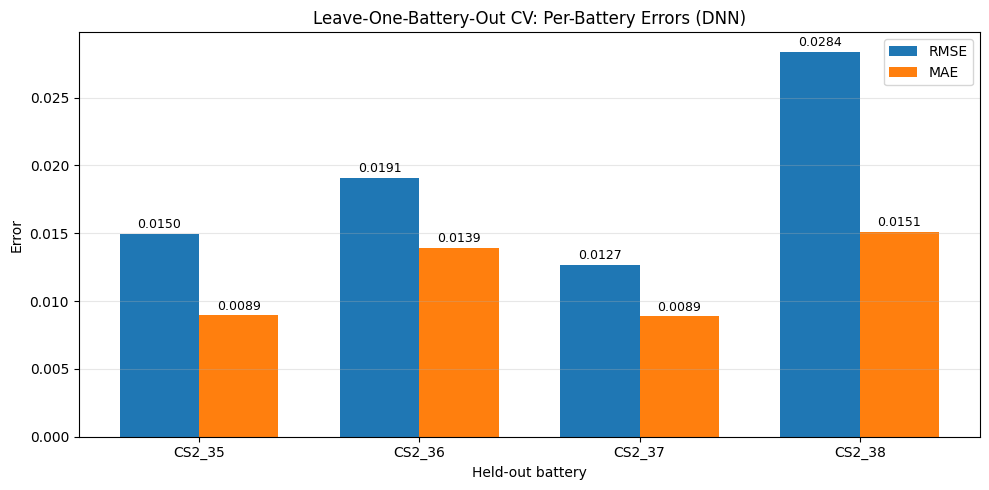

Average RMSE: 0.018781338518000856
Average MAE : 0.011700013652443886


In [31]:
# LOBO-CV visualization: RMSE and MAE per held-out battery
if 'cv_df' not in globals() or cv_df.empty:
    raise RuntimeError("Run Cell 8 first to generate cv_df.")

plot_df = cv_df.copy().sort_values('Holdout_Battery').reset_index(drop=True)
x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, plot_df['RMSE'], width=width, label='RMSE')
ax.bar(x + width / 2, plot_df['MAE'], width=width, label='MAE')

for i, v in enumerate(plot_df['RMSE']):
    ax.text(i - width / 2, v + 0.0002, f"{v:.4f}", ha='center', va='bottom', fontsize=9)
for i, v in enumerate(plot_df['MAE']):
    ax.text(i + width / 2, v + 0.0002, f"{v:.4f}", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_df['Holdout_Battery'])
ax.set_xlabel('Held-out battery')
ax.set_ylabel('Error')
ax.set_title('Leave-One-Battery-Out CV: Per-Battery Errors (DNN)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Average RMSE:', plot_df['RMSE'].mean())
print('Average MAE :', plot_df['MAE'].mean())

Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features used for plotting model: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
Battery     RMSE      MAE
 CS2_35 0.014975 0.008937
 CS2_36 0.019101 0.013917
 CS2_37 0.012663 0.008868
 CS2_38 0.028386 0.015079


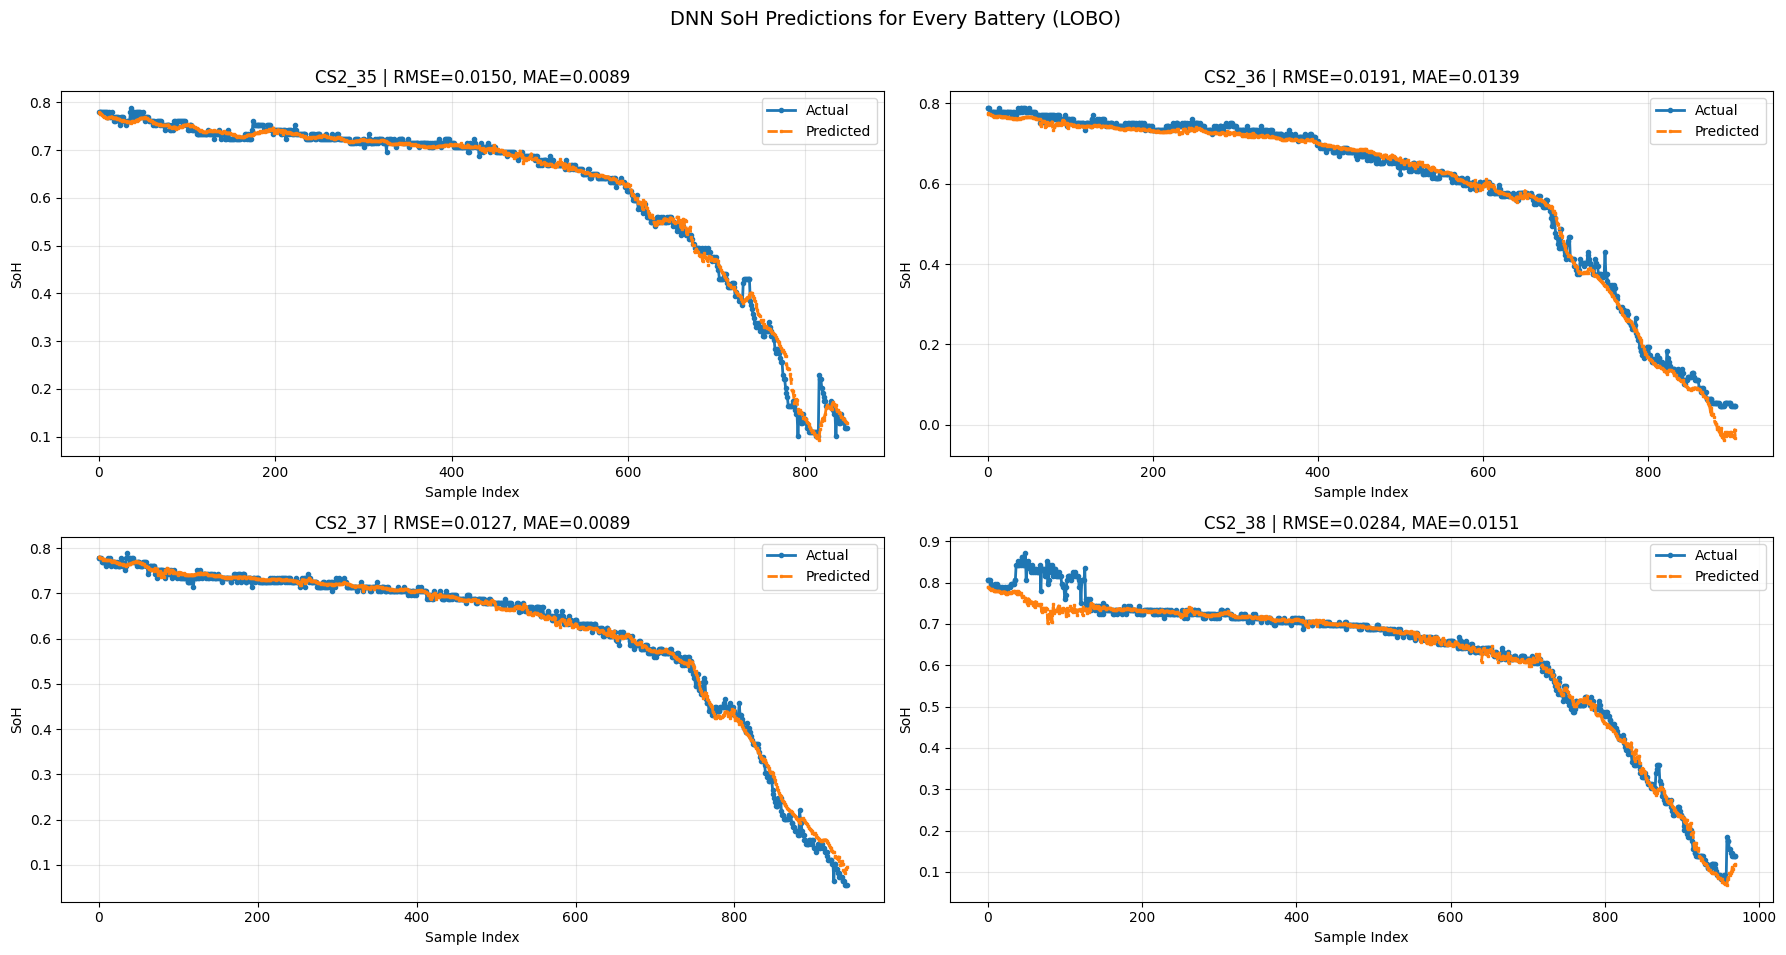

In [32]:
# Visualize predictions for every battery (LOBO with DNN, same setup as Transformer notebook)
setup_seed(42)

plot_rows = []
predictions_by_battery = {}
target_col_plot = 'SoH'

# Use only numeric columns shared by all batteries to avoid column mismatch
common_numeric_cols = sorted(set.intersection(*[
    set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
]))

feature_cols_plot, core_signal_cols_plot, missing_core_signals_plot = select_input_features(
    Battery[Battery_list[0]][common_numeric_cols],
    target_col=target_col_plot,
    require_core_signals=False
)

for holdout_battery in Battery_list:
    train_batteries = [b for b in Battery_list if b != holdout_battery]

    # Build train pool
    X_train_all, y_train_all = [], []
    for b in train_batteries:
        df_bat = Battery[b][feature_cols_plot + [target_col_plot]].dropna().copy()
        X_tmp, y_tmp = build_sequences_multivariate(df_bat, feature_cols_plot, target_col_plot, cv_window_size)
        X_train_all.append(X_tmp)
        y_train_all.append(y_tmp)

    X_train_all = np.vstack(X_train_all)
    y_train_all = np.hstack(y_train_all)

    # Hold-out test
    df_test = Battery[holdout_battery][feature_cols_plot + [target_col_plot]].dropna().copy()
    X_test_raw, y_test_raw = build_sequences_multivariate(df_test, feature_cols_plot, target_col_plot, cv_window_size)

    # Validation split
    X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
        X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
    )

    # Scale (3D -> 2D -> 3D)
    scaler_X_cv = StandardScaler()
    scaler_y_cv = StandardScaler()

    n_train, w_size, n_feat = X_train_raw.shape
    X_train_cv = scaler_X_cv.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

    n_val = X_val_raw.shape[0]
    X_val_cv = scaler_X_cv.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

    n_test = X_test_raw.shape[0]
    X_test_cv = scaler_X_cv.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

    y_train_cv = scaler_y_cv.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
    y_val_cv = scaler_y_cv.transform(y_val_raw.reshape(-1, 1)).ravel()
    y_test_cv = scaler_y_cv.transform(y_test_raw.reshape(-1, 1)).ravel()

    train_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            torch.tensor(X_train_cv, dtype=torch.float32),
            torch.tensor(y_train_cv, dtype=torch.float32)
        ),
        batch_size=cv_batch_size,
        shuffle=True
    )
    val_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            torch.tensor(X_val_cv, dtype=torch.float32),
            torch.tensor(y_val_cv, dtype=torch.float32)
        ),
        batch_size=cv_batch_size,
        shuffle=False
    )
    test_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            torch.tensor(X_test_cv, dtype=torch.float32),
            torch.tensor(y_test_cv, dtype=torch.float32)
        ),
        batch_size=cv_batch_size,
        shuffle=False
    )

    model_cv = DNN_SOHPredictor(window_size=cv_window_size, input_dim=len(feature_cols_plot)).to(device)
    criterion_cv = nn.SmoothL1Loss(beta=0.05)
    optimizer_cv = optim.AdamW(model_cv.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler_cv = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_cv, mode='min', factor=0.5, patience=8, min_lr=1e-5
    )

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(1, cv_max_epochs + 1):
        model_cv.train()
        running_train_loss = 0.0

        for xb, yb in train_loader_cv:
            xb, yb = xb.to(device), yb.to(device)
            optimizer_cv.zero_grad()
            pred = model_cv(xb).squeeze(-1)
            loss = criterion_cv(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_cv.parameters(), max_norm=1.0)
            optimizer_cv.step()
            running_train_loss += loss.item() * xb.size(0)

        model_cv.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader_cv:
                xb, yb = xb.to(device), yb.to(device)
                pred = model_cv(xb).squeeze(-1)
                loss = criterion_cv(pred, yb)
                running_val_loss += loss.item() * xb.size(0)

        val_loss = running_val_loss / len(val_loader_cv.dataset)
        scheduler_cv.step(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model_cv.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= cv_patience:
            break

    if best_state is not None:
        model_cv.load_state_dict(best_state)

    # Predict hold-out battery
    model_cv.eval()
    preds_scaled, targets_scaled = [], []
    with torch.no_grad():
        for xb, yb in test_loader_cv:
            xb = xb.to(device)
            pred = model_cv(xb).squeeze(-1).cpu().numpy()
            preds_scaled.append(pred)
            targets_scaled.append(yb.numpy())

    y_pred_scaled = np.concatenate(preds_scaled)
    y_true_scaled = np.concatenate(targets_scaled)

    y_pred = scaler_y_cv.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y_cv.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    predictions_by_battery[holdout_battery] = {'y_true': y_true, 'y_pred': y_pred}
    plot_rows.append({'Battery': holdout_battery, 'RMSE': rmse, 'MAE': mae})

plot_df = pd.DataFrame(plot_rows).sort_values('Battery').reset_index(drop=True)
print(f"Preferred core inputs found: {core_signal_cols_plot}")
if len(missing_core_signals_plot) > 0:
    print(f"Core inputs not found in this dataset: {missing_core_signals_plot}")
print(f"Features used for plotting model: {feature_cols_plot}")
print(plot_df.to_string(index=False))

# Plot 2x2 subplots for all batteries
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=False, sharey=False)
axes = axes.ravel()

for idx, battery_name in enumerate(sorted(Battery_list)):
    y_true = predictions_by_battery[battery_name]['y_true']
    y_pred = predictions_by_battery[battery_name]['y_pred']
    rmse_b = plot_df.loc[plot_df['Battery'] == battery_name, 'RMSE'].iloc[0]
    mae_b = plot_df.loc[plot_df['Battery'] == battery_name, 'MAE'].iloc[0]

    axes[idx].plot(y_true, label='Actual', linewidth=2, marker='o', markersize=3)
    axes[idx].plot(y_pred, label='Predicted', linewidth=2, linestyle='--', marker='s', markersize=2)
    axes[idx].set_title(f"{battery_name} | RMSE={rmse_b:.4f}, MAE={mae_b:.4f}")
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('SoH')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.suptitle('DNN SoH Predictions for Every Battery (LOBO)', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

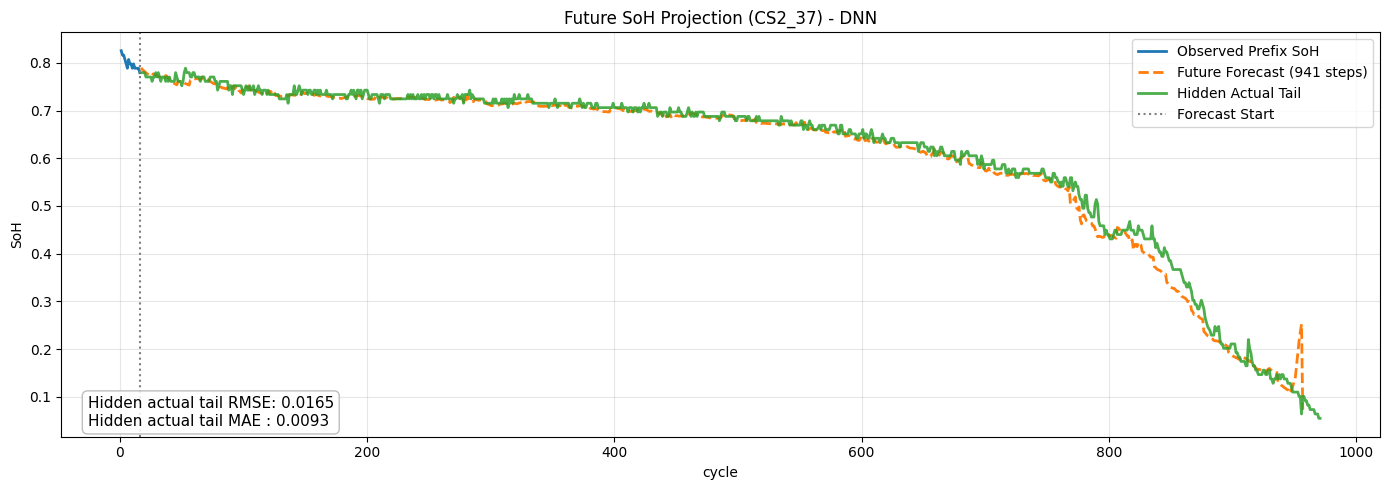

Hidden tail alignment RMSE: 0.016484
Hidden tail alignment MAE : 0.009345


In [33]:
# Future SoH projection using only the observed prefix and direct model rollout
# Transformer-style: set `future_steps`, `forecast_start_mode`, `seed_window_idx`, `guided_refresh_steps`.
future_steps = 'full'            # int (e.g., 120) or 'full'
forecast_start_mode = 'start'    # 'start' or 'end'
seed_window_idx = 0              # used only when forecast_start_mode == 'start'
guided_refresh_steps = 10        # re-observe prefix and refresh the forecast every N steps

# Use the active DNN model (may be tuned and assigned to `model_dnn`)
model_dnn.eval()

if 'future_battery_name' not in globals() or 'X_future_dnn' not in globals() or len(X_future_dnn) == 0:
    raise RuntimeError("Run the DNN train/test cell first to prepare future battery data.")

forecast_battery_name = future_battery_name

# Choose seed window index for autoregressive rollout on future battery
max_seed_idx = len(X_future_dnn) - 1
if forecast_start_mode == 'start':
    seed_idx = int(np.clip(seed_window_idx, 0, max_seed_idx))
else:
    seed_idx = max_seed_idx

y_hist_full = df_future[target_col].values.astype(np.float32)

# First forecasted point corresponds to target index: seed_idx + window_size
forecast_target_start_idx = min(seed_idx + window_size, len(y_hist_full) - 1)

# Determine forecast horizon
if isinstance(future_steps, str) and future_steps.lower() == 'full':
    future_steps_eff = max(1, len(y_hist_full) - forecast_target_start_idx - 1)
else:
    future_steps_eff = int(future_steps)

# Strict real-world context at forecast start
observed_df = df_future.iloc[:forecast_target_start_idx].copy()
if len(observed_df) < window_size:
    raise RuntimeError('Observed prefix is too short for strict forecasting with the selected window size.')

y_hist = observed_df[target_col].values.astype(np.float32)

# Determine x-axis first (prefer cycle-like column)
cycle_like_idx = None
for i, col in enumerate(feature_cols):
    if 'cycle' in col.lower():
        cycle_like_idx = i
        break

if cycle_like_idx is not None:
    x_hist = observed_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    cycle_step = float(np.median(np.diff(x_hist[-min(120, len(x_hist)):]))) if len(x_hist) > 3 else 1.0
    if abs(cycle_step) < 1e-12:
        cycle_step = 1.0
    forecast_start_x = float(x_hist[-1])
    x_future = forecast_start_x + cycle_step * np.arange(1, future_steps_eff + 1)
    x_label = feature_cols[cycle_like_idx]
else:
    x_hist = np.arange(len(observed_df), dtype=np.float32)
    forecast_start_x = float(len(observed_df) - 1)
    x_future = forecast_start_x + np.arange(1, future_steps_eff + 1, dtype=np.float32)
    x_label = 'Sample Index'

# Guided prior + refresh loop (Transformer-style rollout)
guided_refresh_steps = max(1, int(guided_refresh_steps))
future_predictions = []

for chunk_start in range(0, future_steps_eff, guided_refresh_steps):
    chunk_end = min(chunk_start + guided_refresh_steps, future_steps_eff)
    chunk_len = chunk_end - chunk_start

    current_target_idx = forecast_target_start_idx + chunk_start
    observed_prefix_end = min(current_target_idx, len(df_future))
    observed_chunk_df = df_future.iloc[:observed_prefix_end].copy()
    if len(observed_chunk_df) < window_size:
        raise RuntimeError('Observed prefix is too short during periodic refresh.')

    seed_idx_chunk = int(np.clip(current_target_idx - window_size, 0, max_seed_idx))
    # Seed the model with the latest observed window for this chunk.
    window_scaled = torch.tensor(X_future_dnn[seed_idx_chunk], dtype=torch.float32, device=device).unsqueeze(0)

    n_feat = len(feature_cols)
    feature_step_scaled = np.zeros(n_feat, dtype=np.float32)
    for i, col in enumerate(feature_cols):
        vals = observed_chunk_df[col].values.astype(np.float32)
        if len(vals) > 3:
            deltas = np.diff(vals[-min(120, len(vals)):])
            step_raw = float(np.median(deltas)) if len(deltas) > 0 else 0.0
        else:
            step_raw = 0.0
        scale_i = float(scaler_X_dnn.scale_[i])
        feature_step_scaled[i] = step_raw / scale_i if abs(scale_i) > 1e-12 else 0.0

    feature_step_scaled_t = torch.tensor(feature_step_scaled, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(chunk_len):
            pred_scaled = model_dnn(window_scaled).squeeze(-1).item()
            future_predictions.append(pred_scaled)

            # Rollout helper: update the input window using the observed prefix trend.
            next_step = window_scaled[:, -1, :].clone() + feature_step_scaled_t
            window_scaled = torch.cat([window_scaled[:, 1:, :], next_step.unsqueeze(1)], dim=1)

future_predictions_dnn = scaler_y_dnn.inverse_transform(np.array(future_predictions, dtype=np.float32).reshape(-1, 1)).ravel()

# Evaluation only: compare the forecast against the hidden actual tail.
hidden_actual_df = df_future.iloc[forecast_target_start_idx:forecast_target_start_idx + len(future_predictions_dnn)].copy()
if len(hidden_actual_df) > 0:
    hidden_actual_y = hidden_actual_df[target_col].values.astype(np.float32)
    if cycle_like_idx is not None:
        hidden_actual_x = hidden_actual_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    else:
        hidden_actual_x = np.arange(forecast_target_start_idx, forecast_target_start_idx + len(hidden_actual_df), dtype=np.float32)
    compare_len = min(len(hidden_actual_y), len(future_predictions_dnn))
    projection_rmse = np.sqrt(mean_squared_error(hidden_actual_y[:compare_len], future_predictions_dnn[:compare_len]))
    projection_mae = mean_absolute_error(hidden_actual_y[:compare_len], future_predictions_dnn[:compare_len])
else:
    hidden_actual_y = np.array([], dtype=np.float32)
    hidden_actual_x = np.array([], dtype=np.float32)
    projection_rmse = None
    projection_mae = None

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(x_hist, y_hist, label='Observed Prefix SoH', linewidth=2)
ax.plot(x_future, future_predictions_dnn, label=f'Future Forecast ({future_steps_eff} steps)', linewidth=2, linestyle='--')
if len(hidden_actual_y) > 0:
    ax.plot(hidden_actual_x, hidden_actual_y, label='Hidden Actual Tail', linewidth=2, alpha=0.85)

ax.axvline(x=forecast_start_x, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title(f"Future SoH Projection ({forecast_battery_name}) - DNN")
ax.set_xlabel(x_label)
ax.set_ylabel('SoH')
ax.grid(True, alpha=0.3)
ax.legend()
if projection_rmse is not None:
    metric_text = f'Hidden actual tail RMSE: {projection_rmse:.4f}\nHidden actual tail MAE : {projection_mae:.4f}'
    ax.text(
        0.02,
        0.02,
        metric_text,
        transform=ax.transAxes,
        va='bottom',
        ha='left',
        fontsize=11,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.7')
    )
plt.tight_layout()
plt.show()

if projection_rmse is not None:
    print(f"Hidden tail alignment RMSE: {projection_rmse:.6f}")
    print(f"Hidden tail alignment MAE : {projection_mae:.6f}")

In [34]:
# Export DNN future projection for cross-model comparison notebook
import numpy as np
import pandas as pd

pred = None
if 'future_predictions_dnn' in globals():
    pred = np.asarray(future_predictions_dnn).ravel()
elif 'future_predictions' in globals():
    pred = np.asarray(future_predictions).ravel()
else:
    raise RuntimeError('Run the DNN future projection cell first (future_predictions_dnn/future_predictions not found).')

if 'x_future' in globals() and len(np.asarray(x_future).ravel()) == len(pred):
    step = np.asarray(x_future).ravel()
else:
    step = np.arange(1, len(pred) + 1)

out_df = pd.DataFrame({
    'forecast_step': step,
    'predicted_soh': pred,
})

if 'hidden_actual_y' in globals() and len(np.asarray(hidden_actual_y).ravel()) >= len(pred):
    out_df['actual_soh'] = np.asarray(hidden_actual_y).ravel()[:len(pred)]

out_df.to_csv('dnn_future_projection.csv', index=False)
print('Saved dnn_future_projection.csv with rows:', len(out_df))

Saved dnn_future_projection.csv with rows: 941


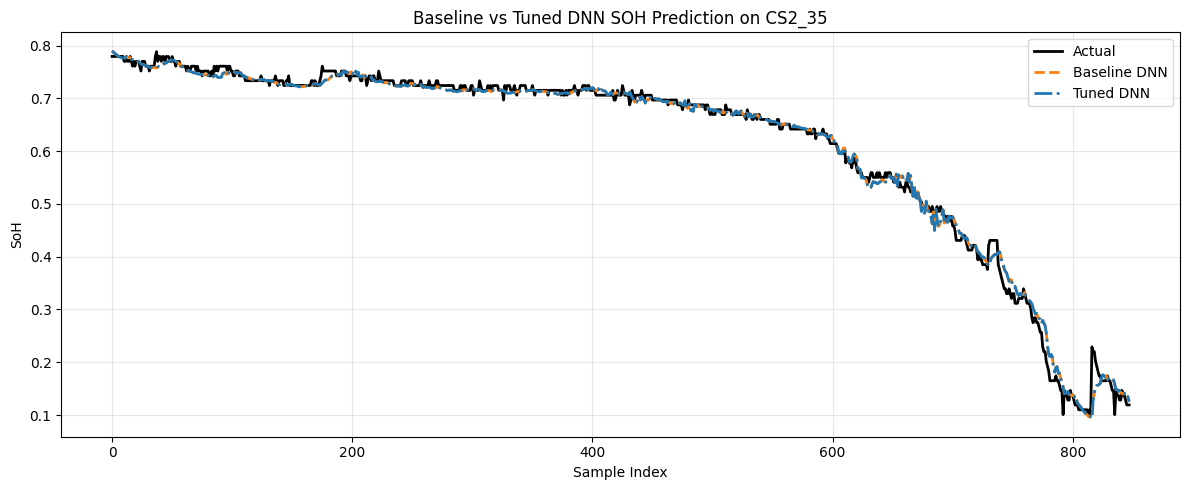

In [35]:
# Baseline vs tuned DNN prediction curves on the hold-out battery
required_vars = [
    'y_test_true_base_dnn',
    'y_pred_test_base_dnn',
    'y_test_true_dnn',
    'y_pred_test_dnn',
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        'Missing prediction variables: ' + ', '.join(missing) + '. Run the baseline and tuning cells first.'
    )

n_base = min(len(y_test_true_base_dnn), len(y_pred_test_base_dnn))
n_tuned = min(len(y_test_true_dnn), len(y_pred_test_dnn))
n_cmp = min(n_base, n_tuned)

x_axis = np.arange(n_cmp)
y_true_cmp = np.asarray(y_test_true_dnn[:n_cmp]).ravel()
y_base_cmp = np.asarray(y_pred_test_base_dnn[:n_cmp]).ravel()
y_tuned_cmp = np.asarray(y_pred_test_dnn[:n_cmp]).ravel()

plt.figure(figsize=(12, 5))
plt.plot(x_axis, y_true_cmp, label='Actual', color='black', linewidth=2)
plt.plot(x_axis, y_base_cmp, label='Baseline DNN', linestyle='--', linewidth=2, color='tab:orange')
plt.plot(x_axis, y_tuned_cmp, label='Tuned DNN', linestyle='-.', linewidth=2, color='tab:blue')
plt.title('Baseline vs Tuned DNN SOH Prediction on CS2_35')
plt.xlabel('Sample Index')
plt.ylabel('SoH')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

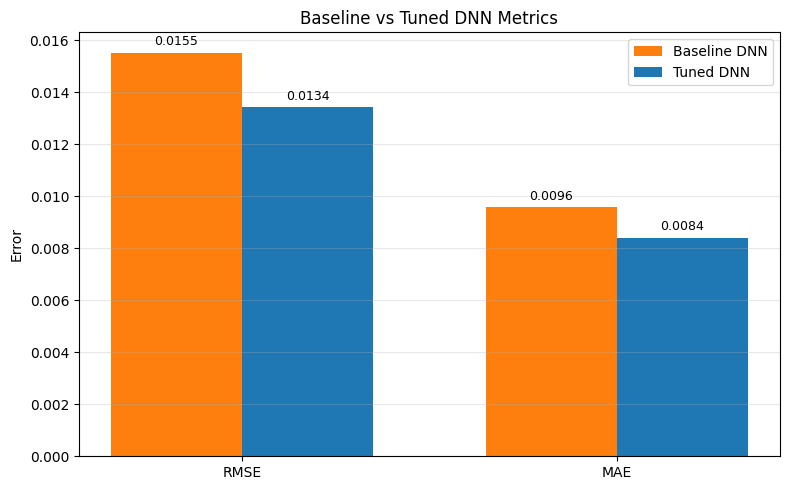

Baseline vs Tuned DNN on hold-out battery (lower is better)
Metric  Baseline    Tuned  Improvement_%
  RMSE  0.015524 0.013426      13.512434
   MAE  0.009588 0.008407      12.311209

Saved: dnn_baseline_vs_tuned_comparison.csv


In [36]:
# Baseline vs tuned DNN metric comparison on the hold-out battery
required_metric_vars = ['rmse_dnn', 'mae_dnn', 'rmse_dnn_tuned', 'mae_dnn_tuned']
missing_metric_vars = [v for v in required_metric_vars if v not in globals()]
if missing_metric_vars:
    raise RuntimeError(
        'Missing metrics: ' + ', '.join(missing_metric_vars) + '. Run the baseline and tuning cells first.'
    )

comparison_dnn = pd.DataFrame({
    'Model': ['Baseline DNN', 'Tuned DNN'],
    'RMSE': [float(rmse_dnn), float(rmse_dnn_tuned)],
    'MAE': [float(mae_dnn), float(mae_dnn_tuned)],
})

baseline_rmse = comparison_dnn.loc[0, 'RMSE']
baseline_mae = comparison_dnn.loc[0, 'MAE']
tuned_rmse = comparison_dnn.loc[1, 'RMSE']
tuned_mae = comparison_dnn.loc[1, 'MAE']

rmse_improvement_pct = (baseline_rmse - tuned_rmse) / baseline_rmse * 100.0 if baseline_rmse != 0 else np.nan
mae_improvement_pct = (baseline_mae - tuned_mae) / baseline_mae * 100.0 if baseline_mae != 0 else np.nan

summary = pd.DataFrame({
    'Metric': ['RMSE', 'MAE'],
    'Baseline': [baseline_rmse, baseline_mae],
    'Tuned': [tuned_rmse, tuned_mae],
    'Improvement_%': [rmse_improvement_pct, mae_improvement_pct],
})

metrics = ['RMSE', 'MAE']
baseline_vals = [baseline_rmse, baseline_mae]
tuned_vals = [tuned_rmse, tuned_mae]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_base = ax.bar(x - width / 2, baseline_vals, width, label='Baseline DNN', color='tab:orange')
bars_tuned = ax.bar(x + width / 2, tuned_vals, width, label='Tuned DNN', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Error')
ax.set_title('Baseline vs Tuned DNN Metrics')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()

for bar in list(bars_base) + list(bars_tuned):
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Baseline vs Tuned DNN on hold-out battery (lower is better)')
print(summary.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

summary.to_csv('dnn_baseline_vs_tuned_comparison.csv', index=False)
print('\nSaved: dnn_baseline_vs_tuned_comparison.csv')